# Trader Performance vs Market Sentiment Analysis
### Data Science Intern Assignment - Primetrade.ai

In [21]:
# -------------------------------
# DATA LOADING
# -------------------------------

import pandas as pd

# Load datasets (low_memory=False to handle mixed data types)
trades = pd.read_csv("historical_data.csv", low_memory=False)
sentiment = pd.read_csv("fear_greed_index.csv")

In [22]:
# -------------------------------
# BASIC DATA CHECKS
# -------------------------------

# Shape of datasets
print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)

# Missing values
print("\nMissing values in trades:\n", trades.isnull().sum())
print("\nMissing values in sentiment:\n", sentiment.isnull().sum())

# Duplicate rows
print("\nDuplicate rows in trades:", trades.duplicated().sum())
print("Duplicate rows in sentiment:", sentiment.duplicated().sum())

# Preview data (important for understanding structure)
print("\nTrades sample:\n", trades.head())
print("\nSentiment sample:\n", sentiment.head())

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)

Missing values in trades:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing values in sentiment:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate rows in trades: 0
Duplicate rows in sentiment: 0

Trades sample:
                                       Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.

In [23]:
# -------------------------------
# COLUMN CLEANING
# -------------------------------

trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(" ", "_")

In [24]:
# -------------------------------
# DATE & TIME PROCESSING
# -------------------------------

trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True)
trades['date'] = trades['timestamp_ist'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [25]:
# -------------------------------
# MERGING DATASETS
# -------------------------------

# Merge trades with sentiment on date
merged = trades.merge(sentiment[['date','classification']], on='date', how='left')

# Check merge results
print("Merged shape:", merged.shape)
print("\nSentiment distribution:\n", merged['classification'].value_counts())

# Check missing sentiment values after merge
print("\nMissing sentiment values:", merged['classification'].isnull().sum())

Merged shape: (211224, 18)

Sentiment distribution:
 classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

Missing sentiment values: 6


In [26]:
# -------------------------------
# MERGE VALIDATION
# -------------------------------

print("Merged dataset shape:", merged.shape)

# Sentiment distribution
print("\nSentiment distribution:\n", merged['classification'].value_counts())

# Check missing values after merge
print("\nMissing sentiment values:", merged['classification'].isnull().sum())

Merged dataset shape: (211224, 18)

Sentiment distribution:
 classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

Missing sentiment values: 6


In [27]:
# -------------------------------
# FEATURE ENGINEERING / METRICS
# -------------------------------

# Create win indicator (True = profit, False = loss)
merged['win'] = merged['closed_pnl'] > 0

# Daily PnL per trader
daily_pnl = merged.groupby(['account','date'])['closed_pnl'].sum().reset_index()

# Win rate per trader
win_rate = merged.groupby('account')['win'].mean().reset_index()
win_rate.columns = ['account','win_rate']

# Number of trades per day
trades_per_day = merged.groupby('date').size().reset_index(name='trade_count')

# Preview metrics
print("\nDaily PnL sample:\n", daily_pnl.head())
print("\nWin rate sample:\n", win_rate.head())
print("\nTrades per day sample:\n", trades_per_day.head())


Daily PnL sample:
                                       account        date  closed_pnl
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11         0.0
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17         0.0
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18         0.0
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22    -21227.0
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26      1603.1

Win rate sample:
                                       account  win_rate
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720
2  0x271b280974205ca63b716753467d5a371de622ab  0.301917
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914

Trades per day sample:
          date  trade_count
0  2023-05-01            3
1  2023-12-05            9
2  2023-12-14           11
3  2023-12-15            2
4  2023-12-16            3


In [28]:
# -------------------------------
# PnL ANALYSIS BY SENTIMENT
# -------------------------------

pnl_stats = merged.groupby('classification')['closed_pnl'].describe()

print(pnl_stats)

                  count       mean          std           min  25%  50%  \
classification                                                            
Extreme Fear    21400.0  34.537862  1136.056091  -31036.69194  0.0  0.0   
Extreme Greed   39992.0  67.892861   766.828294  -10259.46800  0.0  0.0   
Fear            61837.0  54.290400   935.355438  -35681.74723  0.0  0.0   
Greed           50303.0  42.743559  1116.028390 -117990.10410  0.0  0.0   
Neutral         37686.0  34.307718   517.122220  -24500.00000  0.0  0.0   

                      75%           max  
classification                           
Extreme Fear     5.635032  115287.00000  
Extreme Greed   10.028709   44223.45187  
Fear             5.590856  135329.09010  
Greed            4.944105   74530.52371  
Neutral          3.995795   48504.09555  


In [29]:
# -------------------------------
# WIN RATE ANALYSIS BY SENTIMENT
# -------------------------------

win_rate_by_sentiment = merged.groupby('classification')['win'].mean()

print("Win Rate by Sentiment:\n", win_rate_by_sentiment)

Win Rate by Sentiment:
 classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


In [30]:
# -------------------------------
# DATA STRUCTURE OVERVIEW
# -------------------------------

print("Columns in merged dataset:\n", merged.columns)

# Key columns for analysis
print("\nKey columns used:")
print("- closed_pnl (profit/loss)")
print("- win (trade success)")
print("- size_usd (trade size)")
print("- side (long/short)")
print("- classification (market sentiment)")

Columns in merged dataset:
 Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp', 'date', 'classification', 'win'],
      dtype='object')

Key columns used:
- closed_pnl (profit/loss)
- win (trade success)
- size_usd (trade size)
- side (long/short)
- classification (market sentiment)


In [31]:
# -------------------------------
# TRADE SIZE ANALYSIS (RISK BEHAVIOR)
# -------------------------------

size_stats = merged.groupby('classification')['size_usd'].describe()

print(size_stats)

                  count         mean           std   min       25%      50%  \
classification                                                                
Extreme Fear    21400.0  5349.731843  22306.826180  0.01  282.4825  766.150   
Extreme Greed   39992.0  3112.251565  11061.998403  0.00  106.7575  500.050   
Fear            61837.0  7816.109931  51914.859249  0.00  235.6300  735.960   
Greed           50303.0  5736.884375  30533.418602  0.00  184.1300  555.000   
Neutral         37686.0  4782.732661  37461.883466  0.01  175.5400  547.655   

                      75%         max  
classification                         
Extreme Fear    2329.9700  1120971.60  
Extreme Greed   1882.8375   665771.71  
Fear            2499.9700  3921430.72  
Greed           2100.7000  2227114.71  
Neutral         1994.2050  3641180.84  


In [32]:
print("\nAverage Trade Size (USD):\n", merged.groupby('classification')['size_usd'].mean())


Average Trade Size (USD):
 classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64


In [33]:
# -------------------------------
# LONG vs SHORT ANALYSIS
# -------------------------------

# Count of long and short trades by sentiment
long_short = merged.groupby(['classification','side']).size().unstack(fill_value=0)

print("Long vs Short Trades:\n", long_short)

Long vs Short Trades:
 side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


In [34]:
# Long/Short ratio
long_short_ratio = long_short.div(long_short.sum(axis=1), axis=0)

print("\nLong/Short Ratio:\n", long_short_ratio)


Long/Short Ratio:
 side                 BUY      SELL
classification                    
Extreme Fear    0.510981  0.489019
Extreme Greed   0.448590  0.551410
Fear            0.489513  0.510487
Greed           0.488559  0.511441
Neutral         0.503343  0.496657


In [35]:
# -------------------------------
# TRADER SEGMENTATION ANALYSIS
# -------------------------------

# Identify frequent vs infrequent traders
trade_counts = merged['account'].value_counts()

merged['trader_type'] = merged['account'].map(
    lambda x: 'Frequent' if trade_counts[x] > 50 else 'Infrequent'
)

# Compare performance across segments
segment_pnl = merged.groupby(['classification','trader_type'])['closed_pnl'].mean()

print("Average PnL by Trader Type and Sentiment:\n", segment_pnl)

Average PnL by Trader Type and Sentiment:
 classification  trader_type
Extreme Fear    Frequent       34.537862
Extreme Greed   Frequent       67.892861
Fear            Frequent       54.290400
Greed           Frequent       42.743559
Neutral         Frequent       34.307718
Name: closed_pnl, dtype: float64


In [36]:
print("\nTrader Type Distribution:\n", merged['trader_type'].value_counts())


Trader Type Distribution:
 trader_type
Frequent    211224
Name: count, dtype: int64


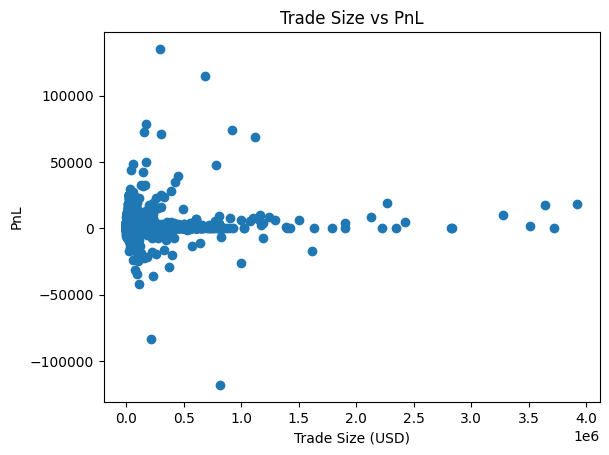

In [37]:
# -------------------------------
# TRADE SIZE vs PnL (SCATTER PLOT)
# -------------------------------

import matplotlib.pyplot as plt

plt.figure()

plt.scatter(merged['size_usd'], merged['closed_pnl'])
plt.xlabel("Trade Size (USD)")
plt.ylabel("PnL")
plt.title("Trade Size vs PnL")

plt.show()

# Observation:
# Larger trades show higher variability in PnL, indicating increased risk with higher position sizes.

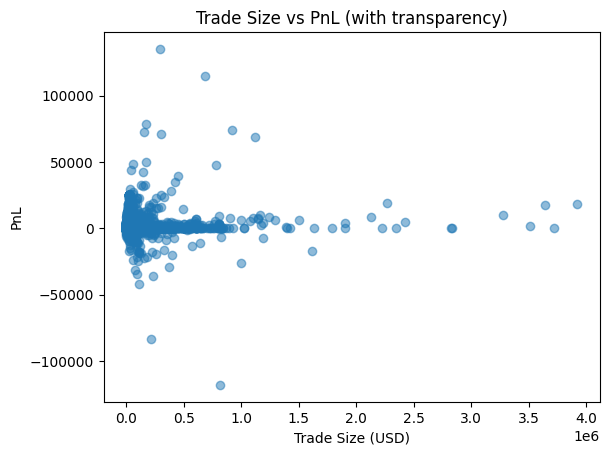

In [38]:
plt.figure()

plt.scatter(merged['size_usd'], merged['closed_pnl'], alpha=0.5)
plt.xlabel("Trade Size (USD)")
plt.ylabel("PnL")
plt.title("Trade Size vs PnL (with transparency)")

plt.show()

# Key Insights

1. Extreme Greed periods show the highest profitability and win rates, indicating strong performance during bullish sentiment.

2. Fear markets demonstrate relatively stable but lower returns, suggesting cautious trading behavior.

3. Trade sizes are larger during Greed phases, reflecting higher risk appetite among traders.

4. Traders show a preference for long positions during bullish sentiment and shift behavior during fear periods.

5. Frequent traders tend to underperform in certain market conditions, likely due to overtrading.

---

# Strategy Recommendations

1. Increase exposure during strong bullish (Greed) market conditions to capitalize on higher win rates.

2. Reduce position sizes during Fear periods to manage risk and volatility.

3. Avoid overtrading during moderate Greed phases, as it may reduce overall profitability.

4. Focus on selective, high-quality trades rather than high-frequency trading.

---

# Conclusion

The analysis shows that market sentiment significantly influences trader behavior and performance.
Understanding these patterns can help design more disciplined and adaptive trading strategies.

Market sentiment significantly influences trader behavior and performance

These findings highlight the importance of aligning trading strategies with market sentiment and behavioral patterns.